# Life Expectancy and Unemployment in Europe: A Data Science Analysis

## Introduction

This project explores the relationship between life expectancy and unemployment in EU countries.

The analysis uses two independent public data sources:
1. WHO: Life expectancy at birth
2. Eurostat data on annual unemployment

The main goal is to examine whether higher unemployment is associated with lower life expectancy across EU countries.



## Research Question and Objectives

This project investigates whether unemployment is associated with life expectancy across EU countries.

### Research question
Is there a relationship between unemployment rate and life expectancy in EU countries between 2003 and 2021?

### Objectives
- To clean and prepare two independent public datasets
- To merge them by country and year
- To describe the distributions of life expectancy and unemployment
- To measure the linear relationship between the two variables
- To interpret the results and discuss their limitations

### Scope
The analysis focuses on 27 EU countries and covers the period from 2003 to 2021.

### Assumptions
This project assumes that the cleaned country-year observations are comparable across the two datasets after matching countries and years correctly.

## Why This Question Matters

Life expectancy is often used as an indicator of population well-being, while unemployment reflects economic and social conditions. Studying these two variables together can help explore whether labour market conditions are associated with broader health outcomes in EU countries.

This question is important because unemployment may be linked to income insecurity, stress, and reduced access to resources, while life expectancy reflects long-term living conditions and public health.


## Data Sources

This project uses two independent public data sources:

1. WHO data on life expectancy at birth
2. Eurostat data on annual unemployment

The objective is to examine whether unemployment is associated with life expectancy across EU countries.

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [227]:
life_path = "../data/raw/life_expectancy_who.csv"
unemp_path = "../data/raw/unemployment_eurostat.csv"

In [228]:
print("Life expectancy file:", life_path)
print("Unemployment file:", unemp_path)

Life expectancy file: ../data/raw/life_expectancy_who.csv
Unemployment file: ../data/raw/unemployment_eurostat.csv


## Methodology

This project follows four main steps:

1. Load the WHO and Eurostat datasets
2. Clean each dataset by keeping only the relevant variables and observations
3. Match countries and merge the datasets by country code and year
4. Analyze the merged data using descriptive statistics, visualizations, and correlation

Pearson correlation is used only for numeric variables in this project, such as life expectancy, unemployment rate, and their year-to-year changes.

This approach makes it possible to compare life expectancy and unemployment across the same countries and years.

## Loading the Raw Data

The first step is to load the two datasets into pandas DataFrames so they can be inspected, cleaned, and prepared for analysis.

In [229]:
life_df = pd.read_csv(life_path)
life_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,IsLatestYear,Dim1 type,Dim1,Dim1ValueCode,Dim2 type,Dim2,Dim2ValueCode,Dim3 type,Dim3,Dim3ValueCode,DataSourceDimValueCode,DataSource,FactValueNumericPrefix,FactValueNumeric,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.73,NaN,NaN,47.80,NaN,49.70,48.7 [47.8-49.7],NaN,NaN,EN,2024-08-01T23:00:00.000Z
1,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,CAF,Central African Republic,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.57,NaN,NaN,48.45,NaN,50.92,49.6 [48.5-50.9],NaN,NaN,EN,2024-08-01T23:00:00.000Z
2,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,True,Sex,Both sexes,SEX_BTSX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.48,NaN,NaN,50.49,NaN,52.57,51.5 [50.5-52.6],NaN,NaN,EN,2024-08-01T23:00:00.000Z
3,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,SWZ,Eswatini,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.64,NaN,NaN,50.73,NaN,52.82,51.6 [50.7-52.8],NaN,NaN,EN,2024-08-01T23:00:00.000Z
4,WHOSIS_000001,Life expectancy at birth (years),text,EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,True,Sex,Male,SEX_MLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.75,NaN,NaN,50.62,NaN,53.10,51.7 [50.6-53.1],NaN,NaN,EN,2024-08-01T23:00:00.000Z


In [230]:
unemp_df = pd.read_csv(unemp_path)
unemp_df.head()

,DATAFLOW,LAST UPDATE,freq,sex,age,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2009,11.3,NaN,NaN
1,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2010,10.1,NaN,NaN
2,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2011,9.5,NaN,NaN
3,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2012,10.0,NaN,NaN
4,ESTAT:TIPSUN20(1.0),12/03/26 23:00:00,A,T,Y15-24,PC_ACT,AT,2013,10.3,NaN,NaN


## Cleaning the Life Expectancy Data

The WHO dataset contains multiple indicators and categories. For this analysis, the data is filtered to keep only life expectancy at birth, EU countries, both sexes, and yearly observations.

In [231]:
life_birth = life_df[
    (life_df["Indicator"] == "Life expectancy at birth (years)") &
    (life_df["ParentLocation"] == "Europe") &
    (life_df["Dim1"] == "Both sexes")
].copy()

life_birth = life_birth[["Location", "Period", "FactValueNumeric"]].copy()

life_birth = life_birth.rename(columns={
    "Location": "country",
    "Period": "year",
    "FactValueNumeric": "life_expectancy"
})

life_birth["year"] = pd.to_numeric(life_birth["year"], errors="coerce")
life_birth["life_expectancy"] = pd.to_numeric(life_birth["life_expectancy"], errors="coerce")

life_birth = life_birth.dropna().sort_values(["country", "year"])

life_birth.head(10)

,country,year,life_expectancy
23686,Albania,2000,73.68
22634,Albania,2001,76.04
21501,Albania,2002,75.49
20371,Albania,2003,74.94
19268,Albania,2004,75.43
18126,Albania,2005,74.21
17008,Albania,2006,74.22
15900,Albania,2007,74.54
14796,Albania,2008,74.99
13691,Albania,2009,75.56


In [232]:
print(life_birth.shape)
print(life_birth["country"].nunique())
print(life_birth["year"].min(), life_birth["year"].max())
print(life_birth["country"].unique()[:20])

(1100, 3)
50
2000 2021
['Albania' 'Armenia' 'Austria' 'Azerbaijan' 'Belarus' 'Belgium'
 'Bosnia and Herzegovina' 'Bulgaria' 'Croatia' 'Cyprus' 'Czechia'
 'Denmark' 'Estonia' 'Finland' 'France' 'Georgia' 'Germany' 'Greece'
 'Hungary' 'Iceland']


## Cleaning the Unemployment Data

The Eurostat dataset is filtered to keep only annual observations, total unemployment, age group 15–74, and percentage of active population. Aggregate regions such as EU totals are removed.

In [233]:
unemp_clean = unemp_df[
    (unemp_df["freq"] == "A") &
    (unemp_df["sex"] == "T") &
    (unemp_df["age"] == "Y15-74") &
    (unemp_df["unit"] == "PC_ACT")
].copy()

unemp_clean = unemp_clean[["geo", "TIME_PERIOD", "OBS_VALUE"]].copy()

unemp_clean = unemp_clean.rename(columns={
    "geo": "geo_code",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "unemployment_rate"
})

unemp_clean["year"] = pd.to_numeric(unemp_clean["year"], errors="coerce")
unemp_clean["unemployment_rate"] = pd.to_numeric(unemp_clean["unemployment_rate"], errors="coerce")

unemp_clean = unemp_clean.dropna()

# keep only 2-letter country codes, remove aggregates like EU27_2020 and EA20
unemp_clean = unemp_clean[unemp_clean["geo_code"].str.len() == 2]

unemp_clean = unemp_clean.sort_values(["geo_code", "year"])

unemp_clean.head(10)

,geo_code,year,unemployment_rate
520,AT,2009,5.7
521,AT,2010,5.2
522,AT,2011,4.9
523,AT,2012,5.2
524,AT,2013,5.7
525,AT,2014,6.0
526,AT,2015,6.1
527,AT,2016,6.5
528,AT,2017,5.9
529,AT,2018,5.2


In [234]:
print(unemp_clean.shape)
print(unemp_clean["geo_code"].nunique())
print(unemp_clean["year"].min(), unemp_clean["year"].max())
print(unemp_clean["geo_code"].unique()[:20])

(469, 3)
27
2003 2025
['AT' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES' 'FI' 'FR' 'HR' 'HU'
 'IE' 'IT' 'LT' 'LU' 'LV' 'MT']


## Matching Countries for Merging

The WHO dataset uses country names, while the Eurostat dataset uses two-letter country codes. A mapping is created so the two datasets can be merged correctly.

In [235]:
country_to_code = {
    "Austria": "AT",
    "Belgium": "BE",
    "Bulgaria": "BG",
    "Croatia": "HR",
    "Cyprus": "CY",
    "Czechia": "CZ",
    "Denmark": "DK",
    "Estonia": "EE",
    "Finland": "FI",
    "France": "FR",
    "Germany": "DE",
    "Greece": "EL",
    "Hungary": "HU",
    "Ireland": "IE",
    "Italy": "IT",
    "Latvia": "LV",
    "Lithuania": "LT",
    "Luxembourg": "LU",
    "Malta": "MT",
    "Netherlands (Kingdom of the)": "NL",
    "Poland": "PL",
    "Portugal": "PT",
    "Romania": "RO",
    "Slovakia": "SK",
    "Slovenia": "SI",
    "Spain": "ES",
    "Sweden": "SE"
}

life_birth["geo_code"] = life_birth["country"].map(country_to_code)

life_eu = life_birth.dropna(subset=["geo_code"]).copy()

life_eu.head(10)

,country,year,life_expectancy,geo_code
23808,Austria,2000,78.18,AT
22700,Austria,2001,78.64,AT
21591,Austria,2002,78.70,AT
20472,Austria,2003,78.63,AT
19369,Austria,2004,79.11,AT
18257,Austria,2005,79.33,AT
17151,Austria,2006,79.81,AT
16036,Austria,2007,80.03,AT
14933,Austria,2008,80.27,AT
13816,Austria,2009,80.12,AT


In [236]:
print(life_eu.shape)
print(life_eu["country"].nunique())
print(sorted(life_eu["geo_code"].unique()))

(594, 4)
27
['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']


## Merging the Datasets

The two cleaned datasets are merged by country code and year. The resulting dataset contains both life expectancy and unemployment rate for the same country and year.

In [237]:
merged_df = pd.merge(
    life_eu,
    unemp_clean,
    on=["geo_code", "year"],
    how="inner"
)

merged_df = merged_df[[
    "country",
    "geo_code",
    "year",
    "life_expectancy",
    "unemployment_rate"
]].sort_values(["country", "year"])

merged_df.head(10)

,country,geo_code,year,life_expectancy,unemployment_rate
0,Austria,AT,2009,80.12,5.7
1,Austria,AT,2010,80.39,5.2
2,Austria,AT,2011,80.74,4.9
3,Austria,AT,2012,80.72,5.2
4,Austria,AT,2013,80.91,5.7
5,Austria,AT,2014,81.24,6.0
6,Austria,AT,2015,80.99,6.1
7,Austria,AT,2016,81.39,6.5
8,Austria,AT,2017,81.39,5.9
9,Austria,AT,2018,81.42,5.2


In [238]:
print(merged_df.shape)
print(merged_df["country"].nunique())
print(merged_df["year"].min(), merged_df["year"].max())

(361, 5)
27
2003 2021


## Mathematical Background

This project uses a few basic statistical ideas to study the data.

### Mean
The mean is the average value.

Mean formula:

$\bar{x} = \frac{x_1 + x_2 + \cdots + x_n}{n}$

In this project, the mean helps show the average life expectancy and the average unemployment rate.

### Median
The median is the middle value when all values are sorted from lowest to highest.

It is useful because it is less affected by very high or very low values.

### Standard Deviation
Standard deviation shows how spread out the values are around the mean.

A low standard deviation means the values are close to the average.  
A high standard deviation means the values are more spread out.

### Correlation
Correlation measures whether two variables move together.

In this project, correlation is used to check whether unemployment and life expectancy have a relationship.

- A positive correlation means both variables tend to increase together.
- A negative correlation means one tends to go up when the other goes down.
- A correlation close to 0 means there is little or no linear relationship.

The correlation coefficient is usually written as:

$r$

## Expected Relationship

Before looking at the data, one possible expectation is that higher unemployment may be associated with lower life expectancy. This would suggest a negative relationship between the two variables.

However, the relationship may be weak because life expectancy depends on many additional factors such as healthcare, education, income, and public policy.



## Descriptive Statistics

After cleaning and merging the two datasets, the next step is to explore the main numerical characteristics of the data.

This section summarizes the central tendency and spread of life expectancy and unemployment rate across the merged observations.

In [239]:
merged_df[["life_expectancy", "unemployment_rate"]].describe()

,life_expectancy,unemployment_rate
count,361.000000,361.000000
mean,79.294654,8.977008
std,2.827511,4.536463
min,71.310000,2.000000
25%,77.090000,6.000000
50%,80.530000,7.900000
75%,81.420000,10.600000
max,83.140000,27.800000


In [240]:
print("Number of rows:", len(merged_df))
print("Number of countries:", merged_df["country"].nunique())
print("Years covered:", merged_df["year"].min(), "-", merged_df["year"].max())

print("\nAverage life expectancy:", round(merged_df["life_expectancy"].mean(), 2))
print("Median life expectancy:", round(merged_df["life_expectancy"].median(), 2))
print("Minimum life expectancy:", round(merged_df["life_expectancy"].min(), 2))
print("Maximum life expectancy:", round(merged_df["life_expectancy"].max(), 2))

print("\nAverage unemployment rate:", round(merged_df["unemployment_rate"].mean(), 2))
print("Median unemployment rate:", round(merged_df["unemployment_rate"].median(), 2))
print("Minimum unemployment rate:", round(merged_df["unemployment_rate"].min(), 2))
print("Maximum unemployment rate:", round(merged_df["unemployment_rate"].max(), 2))

Number of rows: 361
Number of countries: 27
Years covered: 2003 - 2021

Average life expectancy: 79.29
Median life expectancy: 80.53
Minimum life expectancy: 71.31
Maximum life expectancy: 83.14

Average unemployment rate: 8.98
Median unemployment rate: 7.9
Minimum unemployment rate: 2.0
Maximum unemployment rate: 27.8


The merged dataset contains annual observations for 27 EU countries between 2003 and 2021.

Life expectancy is generally high across the dataset, while unemployment shows a wider spread. This suggests that unemployment varies more strongly across countries and years than life expectancy.

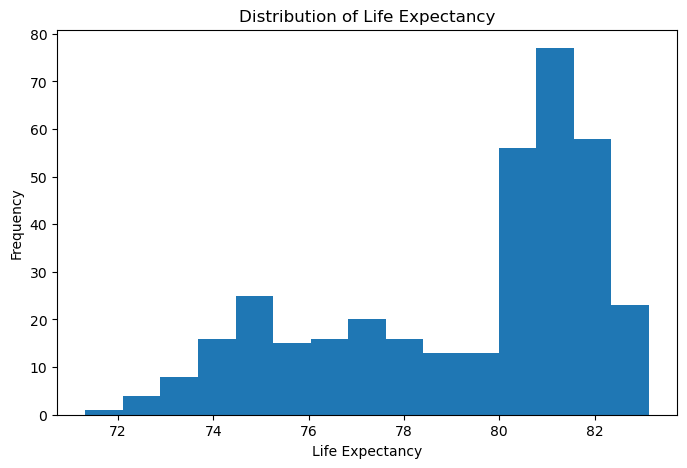

In [241]:
plt.figure(figsize=(8, 5))
plt.hist(merged_df["life_expectancy"], bins=15)
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Life Expectancy")
plt.show()

The distribution of life expectancy is concentrated in the higher range and is not perfectly symmetric. Most values are grouped close to the upper end, while fewer observations appear at the lower end.

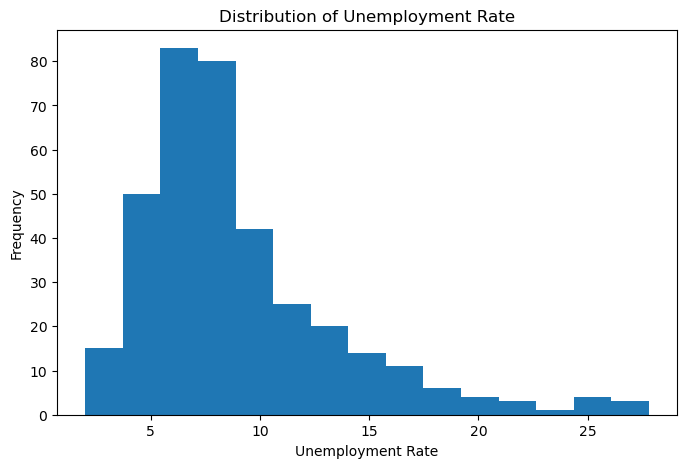

In [242]:
plt.figure(figsize=(8, 5))
plt.hist(merged_df["unemployment_rate"], bins=15)
plt.xlabel("Unemployment Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Unemployment Rate")
plt.show()

The distribution of unemployment is more spread out and appears less symmetric than life expectancy. There are more observations at lower and medium values, with fewer high-unemployment cases.



## Relationship Between Life Expectancy and Unemployment

Next, the relationship between unemployment and life expectancy is examined using a scatter plot, a trend line, Pearson correlation, and Spearman correlation.

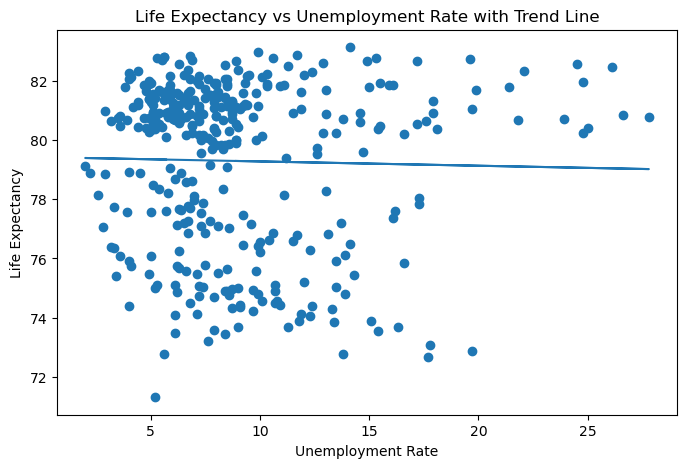

In [243]:
plt.figure(figsize=(8, 5))
plt.scatter(merged_df["unemployment_rate"], merged_df["life_expectancy"])

z = np.polyfit(merged_df["unemployment_rate"], merged_df["life_expectancy"], 1)
p = np.poly1d(z)

plt.plot(merged_df["unemployment_rate"], p(merged_df["unemployment_rate"]))
plt.xlabel("Unemployment Rate")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy vs Unemployment Rate with Trend Line")
plt.show()

In [244]:
correlation = merged_df["life_expectancy"].corr(merged_df["unemployment_rate"])
print("Pearson correlation:", round(correlation, 3))

Pearson correlation: -0.023


In [245]:
spearman_corr = merged_df["life_expectancy"].corr(merged_df["unemployment_rate"], method="spearman")
print("Spearman correlation:", round(spearman_corr, 3))

Spearman correlation: -0.066


Pearson correlation measures the linear relationship between unemployment and life expectancy, while Spearman correlation measures whether the two variables move together in a rank-based way.

If both coefficients are close to 0, this suggests that the relationship is weak not only in a linear sense, but also in terms of overall monotonic association.

## Average Values by Year

In [246]:
year_summary = merged_df.groupby("year")[["life_expectancy", "unemployment_rate"]].mean().round(2)
year_summary.head()

,life_expectancy,unemployment_rate
year,,
2003,79.09,8.50
2004,80.00,8.90
2005,80.21,8.40
2006,80.58,8.05
2007,80.78,7.15


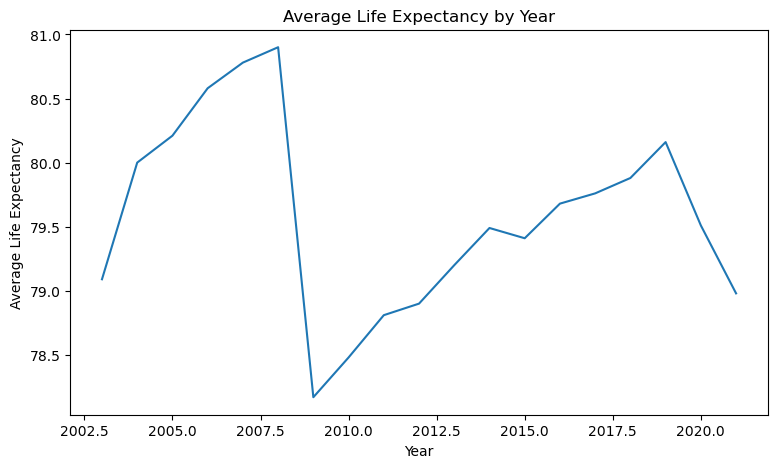

In [247]:
plt.figure(figsize=(9, 5))
plt.plot(year_summary.index, year_summary["life_expectancy"])
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.title("Average Life Expectancy by Year")
plt.show()

The chart shows that average life expectancy changes gradually over time. This is expected, because life expectancy usually moves slowly rather than changing sharply from one year to the next.

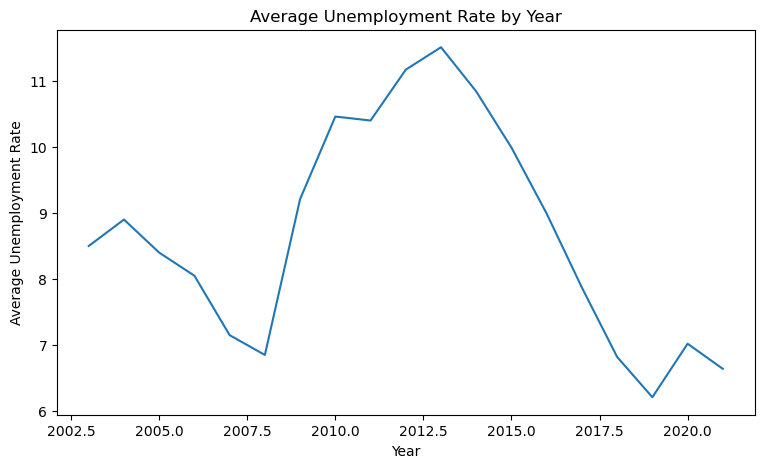

In [248]:
plt.figure(figsize=(9, 5))
plt.plot(year_summary.index, year_summary["unemployment_rate"])
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.title("Average Unemployment Rate by Year")
plt.show()

The unemployment trend shows more variation over time than life expectancy. This supports the earlier observation that unemployment is a more volatile variable.

## Year-to-Year Change Analysis

This section examines whether year-to-year changes in unemployment are associated with year-to-year changes in life expectancy within countries.

Instead of comparing only the levels of the two variables, this part looks at how they change over time.

In [249]:
change_df = merged_df.sort_values(["country", "year"]).copy()

change_df["life_expectancy_change"] = change_df.groupby("country")["life_expectancy"].diff()
change_df["unemployment_change"] = change_df.groupby("country")["unemployment_rate"].diff()

change_df = change_df.dropna()

change_df.head(10)

,country,geo_code,year,life_expectancy,unemployment_rate,life_expectancy_change,unemployment_change
1,Austria,AT,2010,80.39,5.2,0.27,-0.5
2,Austria,AT,2011,80.74,4.9,0.35,-0.3
3,Austria,AT,2012,80.72,5.2,-0.02,0.3
4,Austria,AT,2013,80.91,5.7,0.19,0.5
5,Austria,AT,2014,81.24,6.0,0.33,0.3
6,Austria,AT,2015,80.99,6.1,-0.25,0.1
7,Austria,AT,2016,81.39,6.5,0.40,0.4
8,Austria,AT,2017,81.39,5.9,0.00,-0.6
9,Austria,AT,2018,81.42,5.2,0.03,-0.7
10,Austria,AT,2019,81.65,4.8,0.23,-0.4


In [250]:
print(change_df.shape)
print(change_df["country"].nunique())

(334, 7)
27


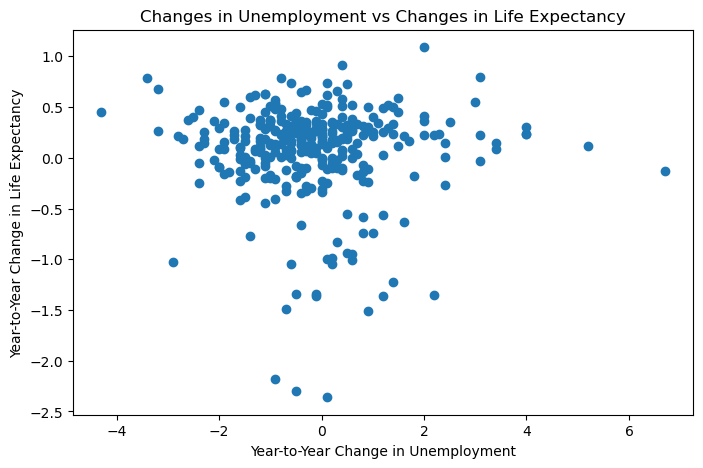

In [251]:
plt.figure(figsize=(8, 5))
plt.scatter(change_df["unemployment_change"], change_df["life_expectancy_change"])
plt.xlabel("Year-to-Year Change in Unemployment")
plt.ylabel("Year-to-Year Change in Life Expectancy")
plt.title("Changes in Unemployment vs Changes in Life Expectancy")
plt.show()

In [252]:
change_corr = change_df["life_expectancy_change"].corr(change_df["unemployment_change"])
print("Pearson correlation of changes:", round(change_corr, 3))

Pearson correlation of changes: -0.035


This analysis focuses on changes rather than levels. It helps examine whether increases or decreases in unemployment are associated with increases or decreases in life expectancy from one year to the next.

If the correlation of changes is also weak, this would support the earlier conclusion that the relationship between the two variables is limited in this dataset.

## Average Values by Country

In [253]:
country_summary = merged_df.groupby("country")[["life_expectancy", "unemployment_rate"]].mean().round(2)
country_summary = country_summary.sort_values("life_expectancy", ascending=False)
country_summary.head(10)

,life_expectancy,unemployment_rate
country,,
Spain,82.31,19.48
Italy,82.27,10.42
Luxembourg,82.15,5.62
Cyprus,81.72,10.23
Sweden,81.60,7.60
Malta,81.45,5.32
France,81.35,9.04
Netherlands (Kingdom of the),81.27,6.16
Ireland,81.07,10.13


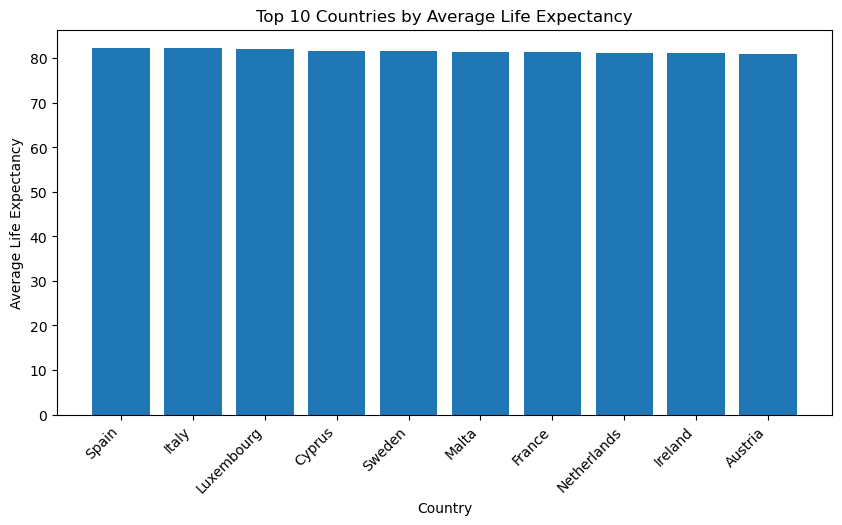

In [254]:
top_life = country_summary.sort_values("life_expectancy", ascending=False).head(10).copy()

top_life.index = top_life.index.str.replace("Netherlands \\(Kingdom of the\\)", "Netherlands", regex=True)

plt.figure(figsize=(10, 5))
plt.bar(top_life.index, top_life["life_expectancy"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("Average Life Expectancy")
plt.title("Top 10 Countries by Average Life Expectancy")
plt.show()

The chart shows the countries with the highest average life expectancy in the merged dataset. This gives a country-level view of the data and adds more detail to the earlier general analysis.

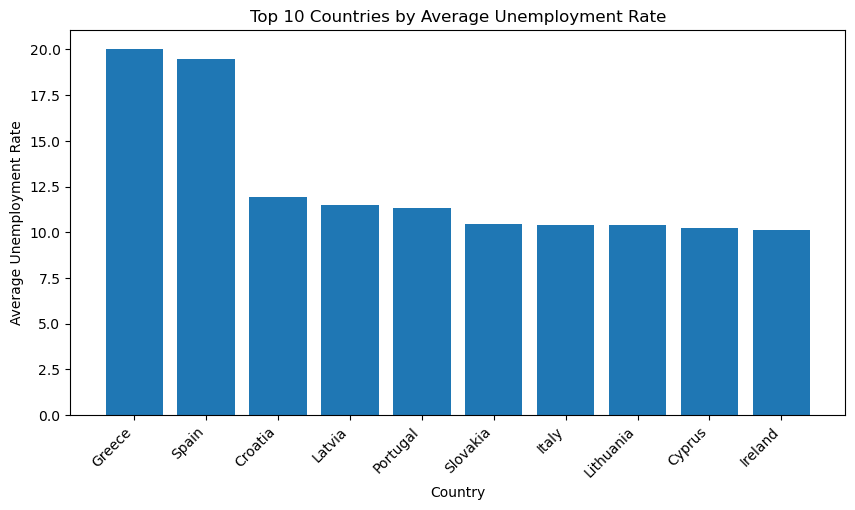

In [255]:
top_unemp = country_summary.sort_values("unemployment_rate", ascending=False).head(10).copy()

top_unemp.index = top_unemp.index.str.replace("Netherlands \\(Kingdom of the\\)", "Netherlands", regex=True)

plt.figure(figsize=(10, 5))
plt.bar(top_unemp.index, top_unemp["unemployment_rate"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("Average Unemployment Rate")
plt.title("Top 10 Countries by Average Unemployment Rate")
plt.show()

This chart shows the countries with the highest average unemployment rate in the merged dataset. It provides an additional country-level comparison and helps balance the earlier focus on life expectancy.

## Comparison by Unemployment Group

This section groups the observations by unemployment level and compares the average life expectancy across these groups.

This makes it possible to see whether observations with lower unemployment tend to have different life expectancy values than observations with higher unemployment.

In [256]:
merged_df["unemp_group"] = pd.qcut(
    merged_df["unemployment_rate"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

merged_df[["unemployment_rate", "unemp_group"]].head(10)

,unemployment_rate,unemp_group
0,5.7,Low
1,5.2,Low
2,4.9,Low
3,5.2,Low
4,5.7,Low
5,6.0,Low
6,6.1,Medium-Low
7,6.5,Medium-Low
8,5.9,Low
9,5.2,Low


In [257]:
group_summary = merged_df.groupby("unemp_group", observed=False)["life_expectancy"].agg(["mean", "median", "std"]).round(2)
group_summary

,mean,median,std
unemp_group,,,
Low,79.91,80.78,2.41
Medium-Low,79.27,80.40,2.63
Medium-High,79.26,80.46,2.87
High,78.73,80.24,3.28


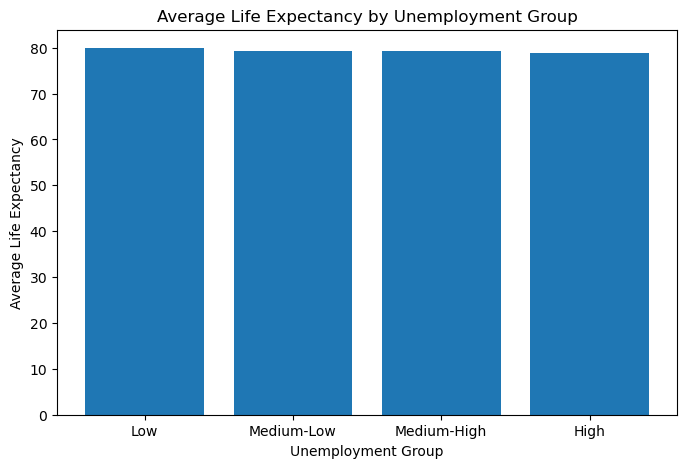

In [258]:
plt.figure(figsize=(8, 5))
plt.bar(group_summary.index, group_summary["mean"])
plt.xlabel("Unemployment Group")
plt.ylabel("Average Life Expectancy")
plt.title("Average Life Expectancy by Unemployment Group")
plt.show()

This grouped comparison shows that average life expectancy differs only slightly across unemployment groups. This is consistent with the earlier correlation results, which suggested that the overall relationship between unemployment and life expectancy is weak in this dataset.

## Limitations

This analysis has several limitations. First, correlation does not imply causation, so the results do not prove that unemployment causes changes in life expectancy. Second, the project uses only two variables, while life expectancy is affected by many other factors such as healthcare quality, income, education, and public policy. Third, the analysis combines countries and years together, which may hide country-specific patterns.

A future extension of the project could include more explanatory variables and separate country-level or time-based analysis.

## Conclusion

This project explored the relationship between life expectancy and unemployment across 27 EU countries between 2003 and 2021 using data from WHO and Eurostat.

After cleaning and merging the datasets, the analysis showed that life expectancy is generally high across EU countries, while unemployment varies more widely across countries and years. The correlation between unemployment and life expectancy was very weak and slightly negative (-0.023).

This suggests that there is no strong linear relationship between the two variables in this dataset. Although unemployment may still matter in specific contexts, life expectancy is influenced by many additional factors such as healthcare access, income, education, and living conditions.

Overall, the project demonstrates how two independent datasets can be cleaned, matched, merged, and analyzed in order to study a real-world question using data science methods.

## References

- World Health Organization (WHO), Global Health Observatory: Life expectancy at birth
- Eurostat: Annual unemployment rate dataset
- SoftUni Final Exam Project Guidelines